In [ ]:
from aeon.benchmarking.published_results import (
    load_classification_bake_off_2023_results,
)
from aeon.visualisation import plot_critical_difference
import polars as pl
import numpy as np
from aeon.datasets.tsc_datasets import univariate
from autotsc import utils


results_arr, datasets, classifiers = load_classification_bake_off_2023_results(
    num_resamples=30, as_array=True
)
results_arr.shape

(112, 34)

In [2]:
res_mine = pl.scan_parquet("s3://tsc-glue/performance-benchmarking/*.parquet").collect()
len(res_mine)

/tmp/ipykernel_840655/2676074629.py:1: UserWarning: '(default_)region' not set; polars will try to get it from bucket

Set the region manually to silence this warning.
  res_mine = pl.scan_parquet("s3://tsc-glue/performance-benchmarking/*.parquet").collect()


12231

In [3]:
pivoted = res_mine.pivot(values="test_accuracy", index="dataset", on="model", aggregate_function='len')
numeric_cols = [c for c in pivoted.columns if c != "dataset"]
sum_row = pl.DataFrame([{"dataset": "all", **{c: pivoted[c].sum() for c in numeric_cols}}]).with_columns([
    pl.col(c).cast(pl.UInt32) for c in numeric_cols
])
result = pl.concat([pivoted, sum_row])
result

dataset,mr-hydra-kbest-5000,loky-stacker-v6,mr-hydra-kbest-10000,mr-hydra-kbest-30000,loky-stacker-v5-soft-et,mr-hydra-kbest-auto,loky-stacker-v5-soft-ridge,loky-stacker-v6-soft-ridge,loky-stacker-v5-soft-rf,loky-stacker-v5-r1,loky-stacker-v6-soft-rf,loky-stacker-v6-soft-et
str,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
"""BeetleFly""",30,8,23,22,4,7,8,0,4,2,1,0
"""PhalangesOutlinesCorrect""",30,9,24,16,4,7,5,2,9,6,0,1
"""ScreenType""",30,6,18,20,3,7,3,2,4,9,0,2
"""ItalyPowerDemand""",30,6,24,24,4,6,3,0,8,12,0,0
"""FordA""",30,9,26,20,5,7,3,1,4,8,1,0
…,…,…,…,…,…,…,…,…,…,…,…,…
"""DistalPhalanxOutlineCorrect""",30,4,24,25,4,8,3,0,2,4,1,0
"""PigAirwayPressure""",30,9,18,20,3,8,6,0,1,10,1,1
"""SonyAIBORobotSurface2""",30,6,19,22,5,8,3,2,2,6,0,0


In [4]:
mine_classifiers = res_mine['model'].unique().to_list()

In [5]:
df_performance = pl.DataFrame(results_arr, schema=classifiers).with_columns(pl.Series("dataset", datasets))
df_performance_mine = res_mine.pivot(values="test_accuracy", index="dataset", on="model", aggregate_function='mean')
df_performance_full = df_performance.join(other=df_performance_mine, on='dataset')

In [6]:
df_performance_full = df_performance_full#.drop(mine_classifiers)
len(df_performance_full)

112

In [7]:
df_performance_full = df_performance_full.drop([col for col in df_performance_full.columns if df_performance_full[col].null_count() > 0])

In [8]:
drop_models = ['ShapeDTW', 'EE', 'ResNet', 'CNN', 
               'CIF', 'BOSS', 'TSFresh', 'Arsenal', 
               'HC1', 'Hydra', '1NN-DTW', 'ROCKET', 
               'Mini-R', 'WEASEL-D', 'InceptionT', 'Signatures', 'RISE', 'DrCIF', 'TDE'
]

In [9]:
df_performance_full = df_performance_full.drop(drop_models)

In [10]:
df_performance_full.columns

['Catch22',
 'FreshPRINCE',
 'HC2',
 'Hydra-MR',
 'MrSQM',
 'Multi-R',
 'PF',
 'RDST',
 'RSF',
 'RSTSF',
 'STC',
 'TS-CHIEF',
 'TSF',
 'WEASEL',
 'cBOSS',
 'dataset',
 'mr-hydra-kbest-5000',
 'loky-stacker-v6',
 'mr-hydra-kbest-10000',
 'mr-hydra-kbest-30000',
 'loky-stacker-v5-soft-et',
 'mr-hydra-kbest-auto',
 'loky-stacker-v5-soft-ridge',
 'loky-stacker-v5-soft-rf',
 'loky-stacker-v5-r1']

(<Figure size 600x430 with 1 Axes>, <Axes: >)

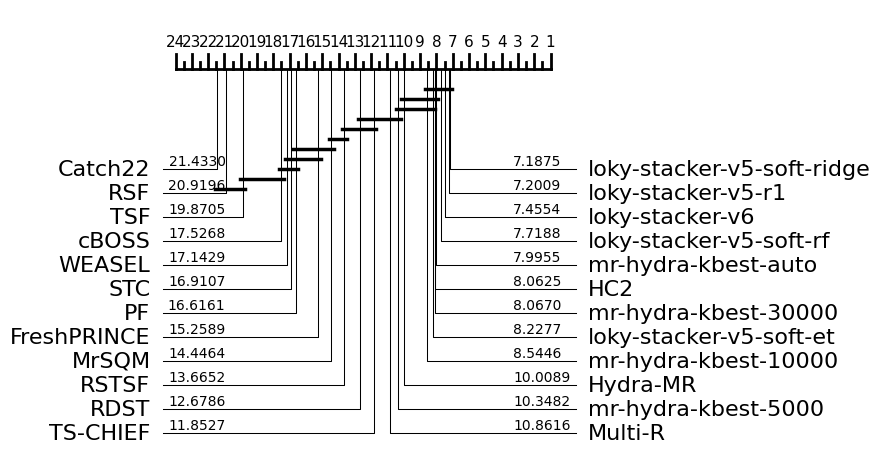

In [11]:
clsf = df_performance_full.select([c for c in df_performance_full.columns if c != "dataset"])
plot_critical_difference(clsf.to_numpy(), clsf.columns)

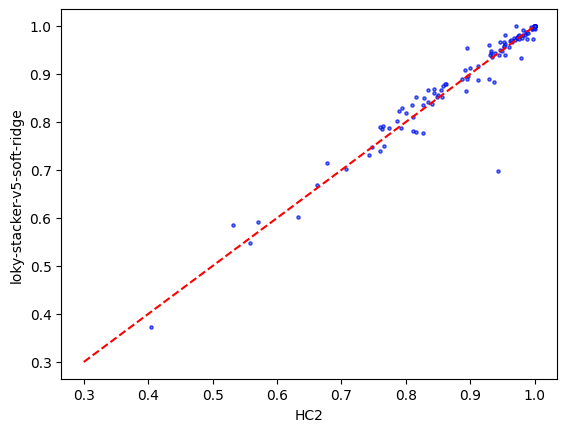

In [12]:
import matplotlib.pyplot as plt

m1 = 'HC2'
m2 = 'loky-stacker-v5-soft-ridge'
plt.scatter(clsf[m1], clsf[m2], alpha=0.7, edgecolors='b', s=5)
plt.xlabel(m1)
plt.ylabel(m2)
plt.plot([0.3, 1], [0.3, 1], 'r--')

In [15]:
def dataset_stats():

    stats = []
    for dataset in univariate:
        X_train, y_train, X_test, y_test = utils.load_dataset(dataset)
        stats.append(
            {
                "dataset": dataset,
                "n_train": X_train.shape[0],
                "n_test": X_test.shape[0],
                "n_classes": len(np.unique(y_train)),
                "series_length": X_train.shape[2],
            }
        )
    return pl.DataFrame(stats)


stats = dataset_stats()

df_performance_full

NameError: name 'univariate' is not defined

In [14]:
#clsf = df_performance_full.select([c for c in df_performance_full.columns if c != "dataset"])
#plot_critical_difference(clsf.to_numpy(), clsf.columns)